---

# LESSON 22: ASSIGNMENT 4 - BAR CHARTS

---

>---
>
>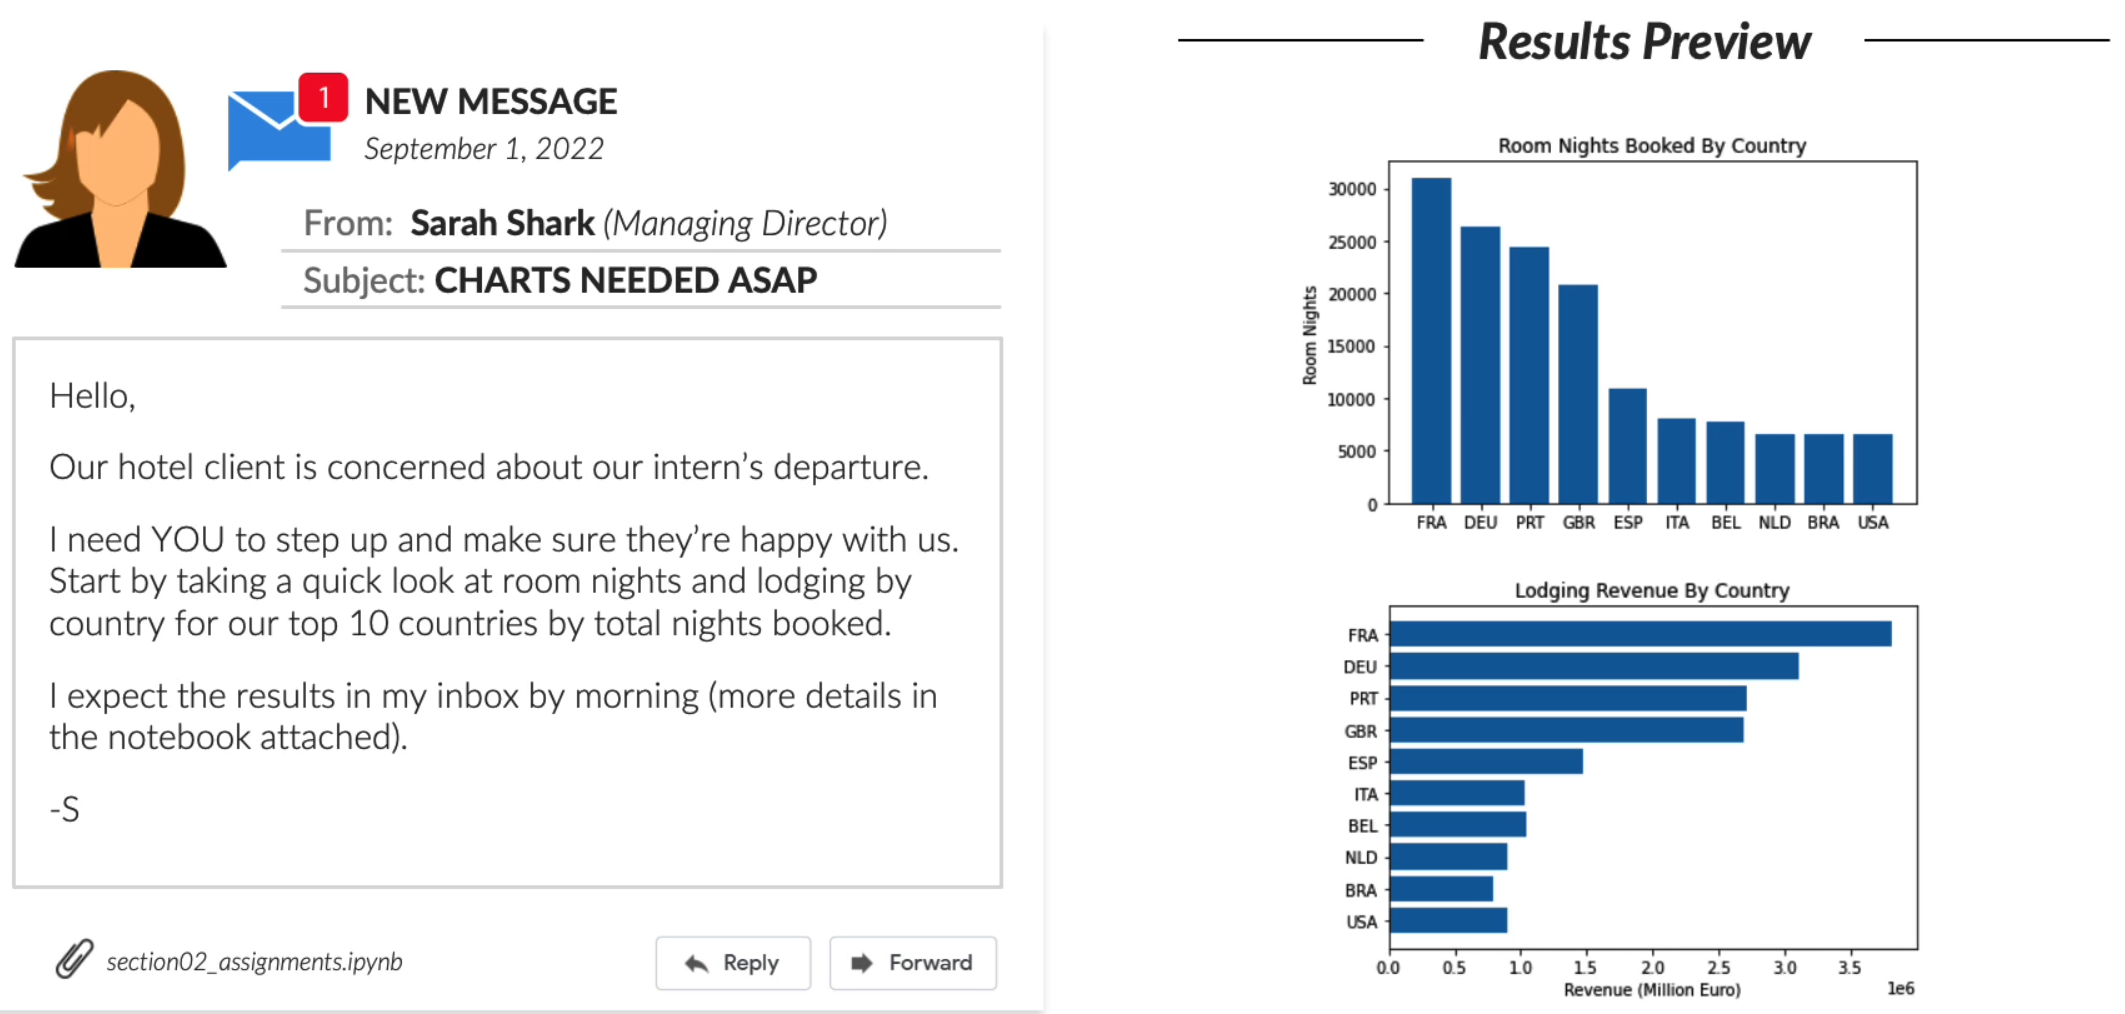
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_excel('../Data/HotelCustomersDataset.xlsx')

df['date'] = (pd.to_datetime('2018-12-31') - pd.to_timedelta(df.DaysSinceCreation, unit='D')).astype('datetime64[ns]')
df = df[['date', 'Nationality', 'RoomNights', 'LodgingRevenue', ]]

df.head()

,date,Nationality,RoomNights,LodgingRevenue
0,2018-08-03,PRT,5,371.0
1,2016-01-01,PRT,5,280.0
2,2016-01-01,DEU,0,0.0
3,2016-01-01,FRA,5,240.0
4,2016-01-01,FRA,0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            83590 non-null  datetime64[ns]
 1   Nationality     83590 non-null  object        
 2   RoomNights      83590 non-null  int64         
 3   LodgingRevenue  83590 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.6+ MB


<br><br>

---

In [4]:
df1 = (df
    .groupby('Nationality')
    .agg({'RoomNights':'sum'})
    .sort_values(by='RoomNights', ascending=False).iloc[:10]
)

df1

,RoomNights
Nationality,
FRA,31018
DEU,26334
PRT,24334
GBR,20822
ESP,10877
ITA,8046
BEL,7758
NLD,6619
BRA,6535


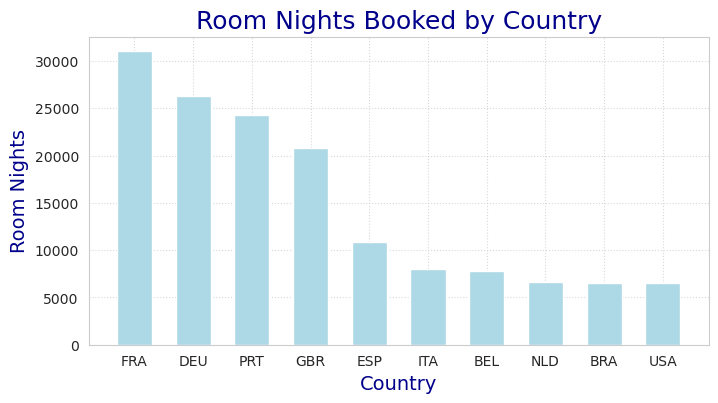

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(df1.index, df1.RoomNights, label='Room Nights',
       width=0.6, color='lightblue')

ax.set_title('Room Nights Booked by Country', fontsize=18,
             color='darkblue')
ax.set_xlabel('Country', fontsize=14, color='darkblue')
ax.set_ylabel('Room Nights', fontsize=14, color='darkblue')

ax.grid(alpha=0.75, ls=':')

plt.show()

In [7]:
df2 = (df
    .groupby('Nationality')
    .agg({'LodgingRevenue':'sum'})
    .sort_values(by='LodgingRevenue', ascending=False)
    .iloc[:10]
)

df2 = df2[::-1]
df2

,LodgingRevenue
Nationality,
BRA,787928.01
USA,903336.11
NLD,904460.78
ITA,1032729.72
BEL,1047661.98
ESP,1475909.33
GBR,2693123.61
PRT,2715008.72
DEU,3113382.55


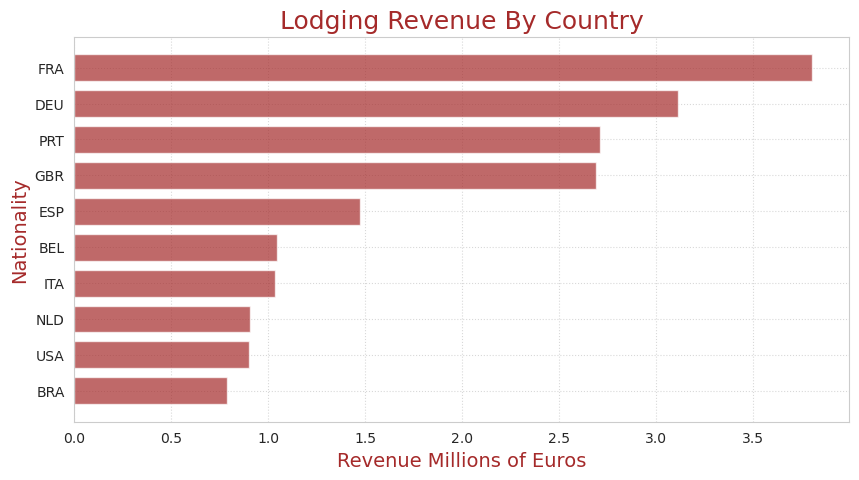

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.barh(df2.index, df2.LodgingRevenue/1e6,
        color='brown', height=0.75, alpha=0.7)

ax.set_title('Lodging Revenue By Country', fontsize=18, color='brown')
ax.set_xlabel('Revenue Millions of Euros', fontsize=14, color='brown')
ax.set_ylabel('Nationality', fontsize=14, color='brown')

ax.grid(alpha=0.75, ls=':')
plt.show()